In [1]:
from collections import namedtuple
import datetime
import itertools
import json
import os
import requests
import sys

from IPython.core.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import scipy
import sklearn

os.chdir('/home/jovyan')

from lib import dataset

%matplotlib inline
%load_ext autoreload
%autoreload 2
plt.style.use("seaborn")
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 500)
display(HTML("<style>.container { width:85% !important; }</style>"))

### Population Data

In [2]:
data = dataset.get_csv(
    url='https://dataverse.harvard.edu/api/access/datafile/3444051?format=original',
    name='presidential_election_results'
)
data.head(3)

Using cached file cache/presidential_election_results.csv


,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party,writein,candidatevotes,totalvotes,version,notes
0,1976,Alabama,AL,1,63,41,US President,"Carter, Jimmy",democrat,False,659170,1182850,20171015,NaN
1,1976,Alabama,AL,1,63,41,US President,"Ford, Gerald",republican,False,504070,1182850,20171015,NaN
2,1976,Alabama,AL,1,63,41,US President,"Maddox, Lester",american independent party,False,9198,1182850,20171015,NaN


In [3]:
party_mapping = {
    'democratic-farmer-labor': 'democrat',
}

# Add party colors
party_colors = {'republican': 'darkred', 'democrat': 'blue', 'other': 'gray'}
parties = sorted(list(party_colors.keys()))

def get_party_group(party):
    if party in ('republican', 'democrat'):
        return party
    else:
        return party_mapping.get(party, 'other')

data_with_parties = data
data_with_parties.loc[:, 'party_group'] = data['party'].apply(get_party_group)
data_with_parties.loc[:, 'party_group_color'] = data['party_group'].map(lambda x: party_colors[x])

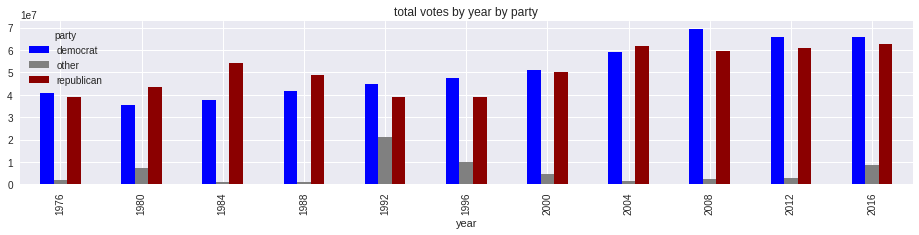

In [4]:
# How many voted for each party?
# TODO: join in number of nonvoters
national_by_year = data_with_parties.pivot_table(
    index='year', 
    columns='party_group', 
    values='candidatevotes', 
    aggfunc='sum'
).rename_axis(columns='party')

national_by_year.plot(
    kind='bar', 
    figsize=(16, 3),
    color=[party_colors[c] for c in national_by_year.columns],
    sort_columns=True)
plt.title('total votes by year by party');

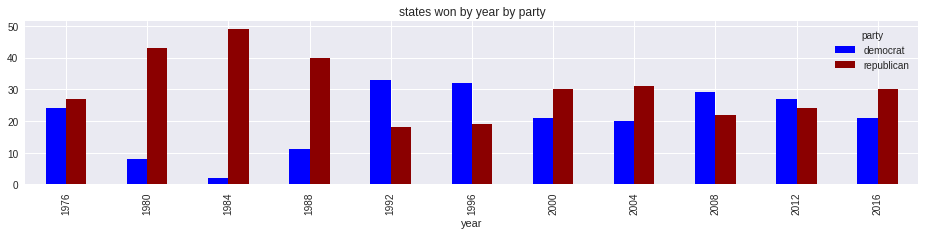

In [5]:
# How many states went for each party?
# Ignoring a couple small idiosyncracies like:
# https://en.wikipedia.org/wiki/Nebraska%27s_2nd_congressional_district
# Hack to get largest row in each group...

states_by_year = (data_with_parties
    .sort_values('candidatevotes', ascending=False)
    .groupby(['year', 'state'])['party_group'].first()
    .reset_index())

state_counts_by_year = (states_by_year
    .pivot_table(
         index='year',
         columns='party_group',
         values='state',
         aggfunc='count')
    .fillna(0))

(state_counts_by_year
     .rename_axis(columns='party')
     .plot(
         kind='bar', 
         figsize=(16, 3), 
         color=[party_colors[c] for c in state_counts_by_year.columns],
         title='states won by year by party',
         sort_columns=True
     )
);

# Fairness

How do we measure how fair an election or a voting system turned out to be?

We might want to think about:
  - consider the electoral college
  - plurality system (will need approximate data on second-preferences)
  - counts of supposed nonvoters due to their votes being wasted
  - estimates of counts of tactical voters / incentives to vote tactically
  - weighting of swing states
  - apportionment between different states, or years
  
---
We'll assume that a two-candidate first-past-the-post election with 100% turnout is perfectly fair, and then examine how unfair US elections actually are as we add in the details of the real world.

Let's start with a relatively simple case - the US presidential election. For now, ignoring non-voters and limiting to the two major candidates - we'll try to add those in later. 

How can we define the value of a single vote in terms that match intuition?  Per "one person, "one vote", all voters _should_ be equally valuable. We will be trying to compare the power of different voters' votes.

Here's a candidate measure of fairness for this simple case:

$$
\text{actual value of a vote} \propto \frac{1}{\text{number of identical votes that would have to be added or removed to change the outcome}}
$$

For example, suppose a national popular election ends up with 55 votes for party A and 45 votes for party B. If 10 voters were added to A or removed from B, the outcome would change (to a tie, which will be irrelevant with larger populations) - we get $\frac{1}{10}$ as the relative value of either party's vote. This number is not meaningful on its own, only for comparison of the value of different voters' votes.

An important feature of this measure is that (at least in a two party race) both party's votes are equally important or unimportant. 

(Is it reasonable for the value of a vote to depend exact results of the election? We're trying to measure the fairness of actual elections accounting for malapportionment, gerrymandering, and the electoral college, among other things - the latter two are intuitively unfair but exactly how injustice is done depends on election results - so yes.)



## Applying this to the U.S. presidential election

We expect to see an effect matching intuition that voting in a non-swing states is not as valuable.

We can incorporate the electoral college like this:

$$
\text{relative value of a voter} \propto \frac{1}{\text{state's spread in votes}} \times 
\frac{\text{state's apportionment of electoral college votes}}{\text{electoral college spread}}
$$

Since $\text{electoral college spread}$ is the same for all voters we can drop it.


### Electoral College Data


We'll need yearly electoral college vote counts, and we'll need to handle (or ignore) the two states that assign EC votes differently - let's ignore for now.

I got electoral college counts off [wikipedia](https://en.wikipedia.org/wiki/United_States_Electoral_College),  
cleaned them up in [this google sheet](https://docs.google.com/spreadsheets/d/1W9iLyLYCgVF3O3Hmk4k8yAXwjJAOQGiOFhnb8D6cUjk/edit?usp=sharing), and copied them into a CSV.

In [6]:
apportionment_data = pd.read_csv('data/electoral_apportionment.csv')
apportionment_by_year = apportionment_data.melt(
    id_vars='state', var_name='year', value_name='electors'
)
apportionment_by_year['year'] = apportionment_by_year['year'].astype(int)
apportionment_by_year.head(1)

,state,year,electors
0,Alabama,1976,9


In [7]:
state_electors = states_by_year.merge(apportionment_by_year, how='left', on=['year', 'state'])
assert state_electors.isnull().sum().sum() == 0
state_electors.head(1)

,year,state,party_group,electors
0,1976,Alabama,democrat,9


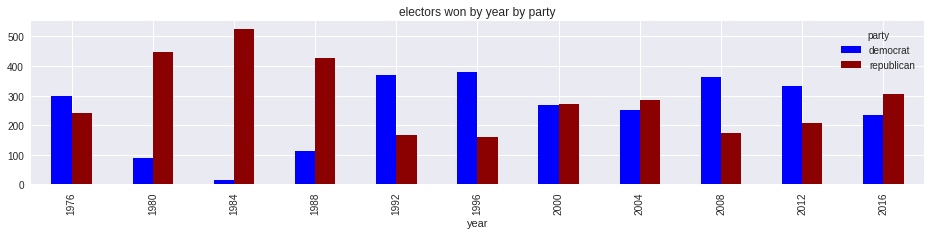

In [8]:
state_electors_by_year = (state_electors
    .pivot_table(
        index='year', 
        columns='party_group',
        values='electors',
        aggfunc='sum'
    )
    .fillna(0)
)
(state_electors_by_year
     .rename_axis(columns='party')
     .plot(
         kind='bar', 
         figsize=(16, 3), 
         color=[party_colors[c] for c in state_electors_by_year.columns],
         title='electors won by year by party',
         sort_columns=True
     )
);


In [52]:
# get to year | state | democrat count | republican count

top_two_parties_data = data_with_parties[data_with_parties['party_group'].isin(['democrat', 'republican'])]
state_votes = top_two_parties_data.pivot_table(
    index=['year', 'state'], 
    columns='party_group',
    values='candidatevotes',
    aggfunc='sum'
).reset_index()

vs = state_votes.merge(apportionment_by_year, how='left', on=['year', 'state'])
vs['winning_party'] = np.where( vs['democrat'] > vs['republican'],'democrat', 'republican')
vs['vote_spread'] =   np.abs(vs['democrat'] - vs['republican'])
relative_value_naive = vs['electors'] / vs['vote_spread']

# Measure of relative value of votes:  |EC votes| / |spread between parties in state|, scaled so that the minimum is 1
vs['value_naive'] = (relative_value_naive / min(relative_value_naive))


### Value of a vote by state: EC-votes-to-spread ratio

In [65]:
year = 2016

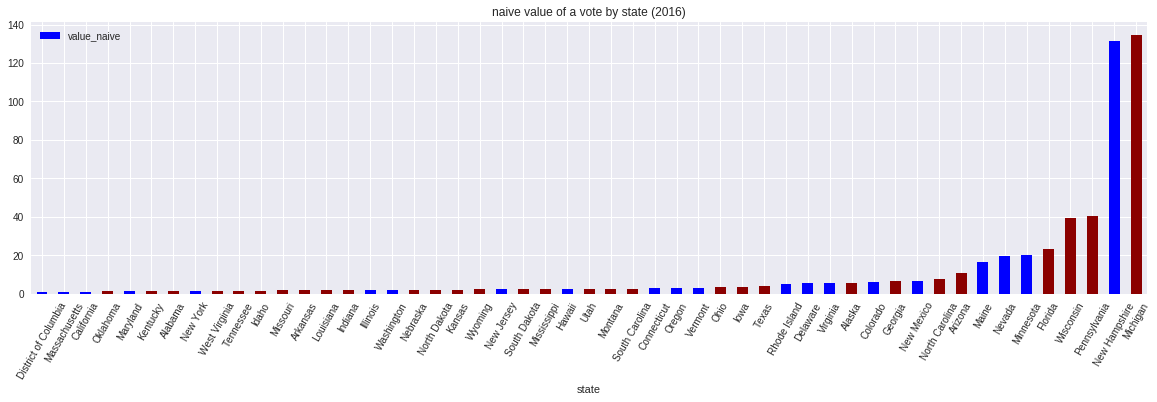

In [70]:
vs_naive = vs[vs.year==year]\
    .sort_values('value_naive', ascending=True)

vs_naive.plot(
    kind='bar', x='state', y='value_naive',
    figsize=(20, 5), rot=60,
    color=vs_naive.winning_party.apply(party_colors.get),
    title=f'naive value of a vote by state ({year})',
);

Pretty interesting! This matches my intuition that a battleground state vote is worth _far_ more than a red or blue bastion.



Issues with this measure:
- The actual values we've found are highly sensitive to the exact margin between candidates in the battleground states, and would go to infinity if a state had an actual tie (in a sense that's correct!) One improvement here would be to apply some kind of regularization representing the lack of information before the election day of exactly close a race will be. The simplest way would probably be to just add a small variance to the turnout of each party and find the expectation of the value of their votes over that joint distribution.
- It seems like the value of a vote should also incorporate the size of the voting population in some way, in the combinatoric sense of "a large population has more ways to reach N votes than a small one". 
- It's a clearly unfair to base our metric so dramatically on the actual election turnout: in battleground states we see tight races, driven by a huge amount of advertising, while in other states we see reduced turnout due to people correctly identifying that their votes were not valuable. We could integrate over a distribution of forecasts, or to consistuency-level polls. But there's a nice simplicity to working with actual turnout: we don't have to deal with any of the inaccuracy or subjectiveness of forecasts and polls.

A few more questions I'm immediately curious to compute:
- How much of the skew between states is solely due to electoral apportionment? Presumably very little.
- How much better would things be if each state assigned its electoral college votes proportional to its own popular vote? The tie-breaking EC vote can got to the state winner or something.
- What is a measure that would characterize the degree of skewness of this entire distribution across the full voting population? Let's look at this over time.
- Apply this measure to Senate votes, considering apportionment
- Apply this measure to House votes, considering apportionment and gerrymandering at the district level.


Brainstormy directions:
- Use a proper measure of [wasted votes](https://en.wikipedia.org/wiki/Wasted_vote)? I don't really buy / understand why you would cound all the votes of the 2nd party as wasted.
- If an election ends up going 60-to-30, what about a measure that says that each of the 60 votes is worth half as much as the 30?



### Alternative measure: turnout-to-EC votes ratio

First, here's a measure based on the ratio of electoral college votes to total voter turnout because it's easy:

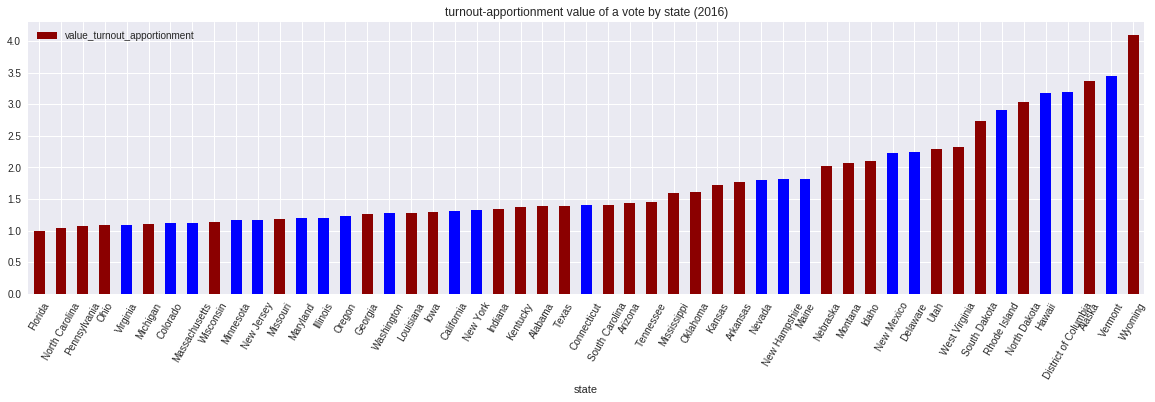

In [74]:
# Measure of relative value of votes:  |EC votes| / |total voter turnout|, scaled so that the minimum is 1
relative_value_turnout_apportionment = vs['electors'] / (vs['democrat'] + vs['republican'])
vs['value_turnout_apportionment'] = relative_value_turnout_apportionment / min(relative_value_turnout_apportionment)

vs_turnout_apportionment = vs[vs.year==year]\
    .sort_values('value_turnout_apportionment', ascending=True)

vs_turnout_apportionment.plot(
    kind='bar', x='state', y='value_turnout_apportionment',
    figsize=(20, 5), rot=60,
    color=vs_turnout_apportionment.winning_party.apply(party_colors.get),
    title=f'turnout-apportionment value of a vote by state ({year})',
);

### Overall fairness

,year,state,democrat,republican,electors,winning_party,vote_spread,value_naive,value_turnout_apportionment
0,1976,Alabama,659170,504070,9,democrat,155100,5.224507,2.433920
1,1976,Alaska,44058,71555,3,republican,27497,9.823144,8.162960
2,1976,Arizona,295602,418642,6,republican,123040,4.390556,2.642638
3,1976,Arkansas,498604,267903,6,democrat,230701,2.341620,2.462454
4,1976,California,3742284,3882244,45,republican,139960,28.948307,1.856661
...,...,...,...,...,...,...,...,...,...
556,2016,Virginia,1981473,1769443,13,democrat,212030,5.520274,1.090283
557,2016,Washington,1742718,1221747,12,democrat,520971,2.073874,1.273409
558,2016,West Virginia,188794,489371,5,republican,300577,1.497714,2.319357
559,2016,Wisconsin,1382536,1405284,10,republican,22748,39.579597,1.128414
